In [1]:
# Import statments

import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fcluster, dendrogram, linkage
from scipy.spatial.distance import squareform
import os
import re

In [2]:
curr_dir = os.getcwd()
base_dir = os.path.dirname(curr_dir)
data_dir = os.path.join(base_dir, 'Data')
temp = os.path.join( data_dir , 'mitopark')
filename = os.path.join( temp , 'session_1_out.mat') 

In [ ]:
# filename = os.path.join( poster_data_dir , '227_session_1_out.mat') 

In [3]:
# If similarity matrix and idx files exist, extract and save them

with h5py.File(filename, 'r') as file:
    if 'Clusters' in file:
        clusters_group = file['Clusters']
        if 'sim' in clusters_group:
            sim_data = clusters_group['sim'][:]
            sim_matrix_data = pd.DataFrame(sim_data)

In [4]:
with h5py.File(filename, 'r') as file:
    if 'Clusters' in file:
        clusters_group = file['Clusters']

        if 'idx' in clusters_group:
            idx_data = clusters_group['idx'][:]
            # clusters_data = pd.DataFrame(idx_data).transpose()

In [6]:
clusters_data = pd.DataFrame(idx_data).transpose()

In [ ]:
# clusters_data_OF = clusters_data.iloc[ : int(3599904/300) ]
# clusters_data_sorted_OF = clusters_data_OF.sort_values(by=0)
# clusters_data_sorted_OF[0] = clusters_data_sorted_OF[0].astype( int )


# clusters_data_SB = clusters_data.iloc[ int(3599904/300) : ]
# clusters_data_sorted_SB = clusters_data_SB.sort_values(by=0)
# clusters_data_sorted_SB[0] = clusters_data_sorted_SB[0].astype( int )

In [ ]:
# n = int(3599904/300)
# clusters_data['O/S'] = ['O' if i < n else 'S' for i in range(len(clusters_data))]
clusters_data = clusters_data.rename(columns={0: 'cluster'})

# Uncomment if you want to save clusters file. Make sure to change name.

# clusters_data.to_csv( '227_clusters.csv')

In [ ]:
# n = int(3599904/300)
# clusters_data['O/S'] = ['O' if i < n else 'S' for i in range(len(clusters_data))]
clusters_data = clusters_data.rename(columns={0: 'cluster'})

# Uncomment if you want to save clusters file. Make sure to change name.

# clusters_data.to_csv( '227_clusters.csv')

In [8]:
#Sort the idx file so that the timstamps are ordered by the cluster 

clusters_data_sorted = clusters_data.sort_values(by='cluster')
clusters_data_sorted['cluster'] = clusters_data_sorted['cluster'].astype( int )

# sim_matrix_data = sim_matrix_data * -1

In [9]:
#  Plot given similarity matrix

def plot_similarity_matrix(sim_matrix, title, xlabel, ylabel, colorbar_threshold=-0.3, save=False, path=None):
    data_array = sim_matrix.to_numpy()
    cluster_labels = sim_matrix.index.astype(str)  
    
    plt.figure(figsize=(12, 9))
    im = plt.imshow(data_array, cmap='Blues', interpolation='nearest', vmin=colorbar_threshold, vmax=0)
    plt.colorbar(im)
    plt.clim(colorbar_threshold, 0)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # Set cluster labels for axes
    plt.xticks(ticks=np.arange(len(cluster_labels)), labels=cluster_labels, rotation=90)
    plt.yticks(ticks=np.arange(len(cluster_labels)), labels=cluster_labels)

    # Save if needed
    if save:
        if path is None:
            safe_title = re.sub(r'[^\w\-_. ]', '_', title).replace(' ', '_')
            path = f"{safe_title}.eps"

        eps_dir = os.path.dirname(path)
        if eps_dir:
            os.makedirs(eps_dir, exist_ok=True)

        base_filename = os.path.splitext(os.path.basename(path))[0]
        eps_path = os.path.join(eps_dir, base_filename + '.eps')
        plt.savefig(eps_path, format='eps', bbox_inches='tight')
        print(f"EPS saved to: {eps_path}")

        parent_dir = os.path.dirname(eps_dir)
        png_dir = os.path.join(parent_dir, 'png')
        os.makedirs(png_dir, exist_ok=True)

        png_path = os.path.join(png_dir, base_filename + '.png')
        plt.savefig(png_path, format='png', dpi=300, bbox_inches='tight')
        print(f"PNG saved to: {png_path}")

    plt.tight_layout()
    plt.show()

MemoryError: Unable to allocate 109. GiB for an array with shape (121067, 121067) and data type float64

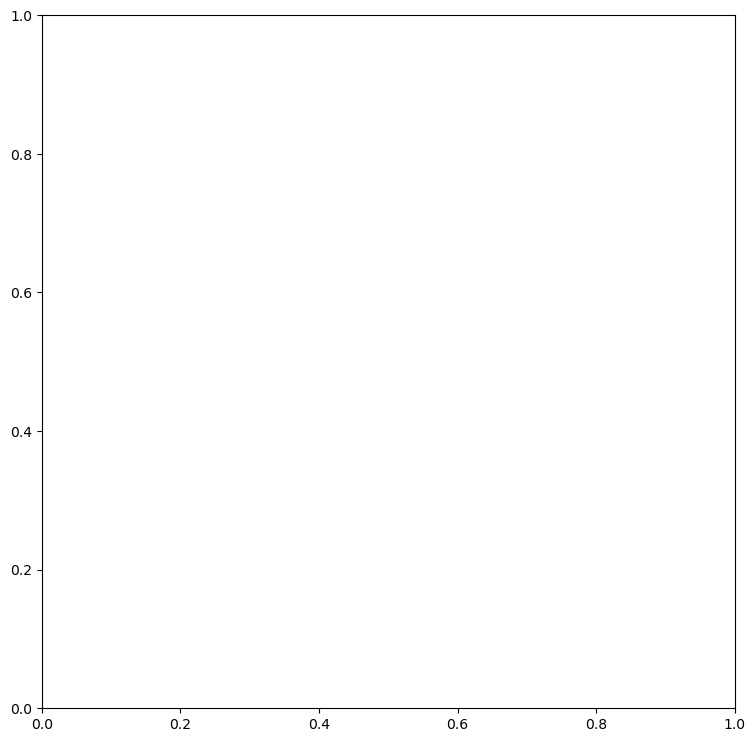

In [10]:
# Plots raw similarity matrix

plt.figure(figsize=(12, 9))
im = plt.imshow(sim_matrix_data.to_numpy(), cmap='Blues', interpolation='nearest', vmin=-0.30, vmax=0)
plt.colorbar(im)
plt.clim(-0.30, 0)
plt.title("Similarity Matrix (Raw)")
plt.xlabel("Time Segment X")
plt.ylabel("Time Segment Y")

plt.show()


In [11]:
# Reorders original similarity matrix by ordering by cluster label instead of timestamp

sorted_indices = clusters_data_sorted.index
reordered_matrix = sim_matrix_data.loc[sorted_indices, sorted_indices]

MemoryError: Unable to allocate 109. GiB for an array with shape (121067, 121067) and data type float64

In [ ]:
#Plots similarity matrix reordered by cluster value --> all of the times with cluster 1 are at the beginning, then 2, etc

# NOTE : if the ordering of the clusters doesn't differ much from orginal to reordered, this matrix will look very similar to the previous one

plt.figure(figsize=(12, 9))
im = plt.imshow(reordered_matrix.to_numpy(), cmap='Blues', interpolation='nearest', vmin=-0.30, vmax=0)
plt.colorbar(im)
plt.clim(-0.30, 0)
plt.title("Similarity Matrix (Reordered)")
plt.xlabel("Time Segment X")
plt.ylabel("Time Segment Y")

plt.show()

In [ ]:
# Figures out how many rows of data exist for each cluster label

cluster_counts = clusters_data_sorted['cluster'].value_counts().reset_index()
cluster_counts.columns = ['cluster', 'count']
cluster_counts = cluster_counts.sort_values(by='cluster')


In [ ]:
# Computes a condensed version of original matrix by averaging together the rows and columns where the cluster label is the same

clusters = cluster_counts['cluster']
counts = cluster_counts['count'].values

final_matrix = np.zeros((len(clusters), len(clusters)))

# Compute averages for each cluster pair
for i, cluster_i in enumerate(clusters):
    for j, cluster_j in enumerate(clusters):
        # Get the indices for rows and columns in the original matrix for the respective clusters
        rows_i = clusters_data_sorted[clusters_data_sorted['cluster'] == cluster_i].index
        rows_j = clusters_data_sorted[clusters_data_sorted['cluster'] == cluster_j].index
        
        # Compute the average of the submatrix
        submatrix = reordered_matrix.loc[rows_i, rows_j]
        # submatrix = sim_matrix_data.loc[rows_i, rows_j]
        final_matrix[i, j] = submatrix.values.mean()

final_matrix_df = pd.DataFrame(final_matrix, index=clusters, columns=clusters)


In [ ]:
# def create_OF_SB_similarity_matrix( sim_matrix_data , switch , clusters_data_sorted_roi ,  OF = True ):
#     if OF:
#         sim_matrix_data_roi = sim_matrix_data.iloc[ : switch, : switch ]
#     else:
#         sim_matrix_data_roi = sim_matrix_data.iloc[ switch : , switch : ]
        
#     sorted_indices_roi = clusters_data_sorted_roi.index
#     reordered_matrix_roi = sim_matrix_data_roi.loc[sorted_indices_roi, sorted_indices_roi]

#     cluster_counts_roi = clusters_data_sorted_roi[0].value_counts().reset_index()
#     cluster_counts_roi.columns = ['cluster', 'count']
#     cluster_counts_roi = cluster_counts_roi.sort_values(by='cluster')

#     clusters_roi = cluster_counts_roi['cluster']
#     counts = cluster_counts_roi['count'].values

#     final_matrix_roi = np.zeros((len(clusters_roi), len(clusters_roi)))

#     # Compute averages for each cluster pair
#     for i, cluster_i in enumerate(clusters_roi):
#         for j, cluster_j in enumerate(clusters_roi):
#             # Get the indices for rows and columns in the original matrix for the respective clusters
#             rows_i = clusters_data_sorted_roi[clusters_data_sorted_roi[0] == cluster_i].index
#             rows_j = clusters_data_sorted_roi[clusters_data_sorted_roi[0] == cluster_j].index
            
#             # Compute the average of the submatrix
#             submatrix = reordered_matrix_roi.loc[rows_i, rows_j]
#             # submatrix = sim_matrix_data.loc[rows_i, rows_j]
#             final_matrix_roi[i, j] = submatrix.values.mean()

#     final_matrix_df_roi = pd.DataFrame(final_matrix_roi, index=clusters_roi, columns=clusters_roi)
#     return final_matrix_df_roi


In [ ]:
# #Plots final similarity matrix where time segments with the same cluster value are averaged together
# save_path = os.path.join( poster_visualizations_dir , 'full_data\eps\sim_matrix.eps')
# plot_similarity_matrix( final_matrix_df , "Similarity Matrix" , "Cluster X" , "Cluster Y" , colorbar_threshold = -0.20 , save = True, path = save_path)

In [ ]:
# OF_sim_matrix = create_OF_SB_similarity_matrix( sim_matrix_data , int(3599904/300) , clusters_data_sorted_OF  )
# save_path = os.path.join( poster_visualizations_dir , 'open_field\eps\OF_sim_matrix.eps')
# plot_similarity_matrix( OF_sim_matrix , "Similarity Matrix Open Field" , "Cluster X" , "Cluster Y" , colorbar_threshold = -0.20 , save=True , path = save_path )

In [ ]:
# SB_sim_matrix = create_OF_SB_similarity_matrix( sim_matrix_data , int(3599904/300) , clusters_data_sorted_SB , OF = False )
# save_path = os.path.join( poster_visualizations_dir , 'social_box\eps\SB_sim_matrix.eps')
# plot_similarity_matrix( SB_sim_matrix , "Similarity Matrix Social Box" , "Cluster X" , "Cluster Y" , colorbar_threshold = -0.20 , save=True , path = save_path )

Similarity matrix divided by timestamps of ROI (divided by which mouse they're interacting with and if they are going in/out)

In [ ]:
# stitched_timestamps_dir = os.path.join( poster_data_dir , '100424_2_RT_112624_StitchedTimestamps' )
# split_timestamps_dir = os.path.join( poster_data_dir , '100424_2_RT_112624_SplitTimestamps' )

# male_df = pd.read_csv(os.path.join( stitched_timestamps_dir , 'ROI_male_both_extracted_w_cluster.csv') , index_col=0 )
# female_df = pd.read_csv( os.path.join( stitched_timestamps_dir , 'ROI_female_both_extracted_w_cluster.csv') , index_col=0)
# bully_df = pd.read_csv( os.path.join( stitched_timestamps_dir , 'ROI_bully_both_extracted_w_cluster.csv') , index_col=0)
# dummy_df = pd.read_csv( os.path.join( stitched_timestamps_dir , 'ROI_dummy_both_extracted_w_cluster.csv') , index_col=0)

# bully_OF_df = pd.read_csv( os.path.join( split_timestamps_dir , 'ROI_bully_OF_both_extracted_w_cluster.csv') , index_col=0 )
# female_OF_df = pd.read_csv( os.path.join( split_timestamps_dir , 'ROI_bully_OF_both_extracted_w_cluster.csv') , index_col=0 )
# male_OF_df = pd.read_csv( os.path.join( split_timestamps_dir , 'ROI_male_OF_both_extracted_w_cluster.csv') , index_col=0 )
# dummy_OF_df = pd.read_csv( os.path.join( split_timestamps_dir , 'ROI_dummy_OF_both_extracted_w_cluster.csv') , index_col=0 )

# bully_SB_df = pd.read_csv( os.path.join(split_timestamps_dir , 'ROI_bully_OF_both_extracted_w_cluster.csv') , index_col=0  )
# female_SB_df = pd.read_csv( os.path.join(split_timestamps_dir , 'ROI_female_OF_both_extracted_w_cluster.csv') , index_col=0  )
# male_SB_df = pd.read_csv( os.path.join(split_timestamps_dir , 'ROI_male_OF_both_extracted_w_cluster.csv') , index_col=0  )
# dummy_SB_df = pd.read_csv( os.path.join(split_timestamps_dir , 'ROI_dummy_OF_both_extracted_w_cluster.csv') , index_col=0  )

In [ ]:
# This code recalculates given roi_similarity_matrix by looking at the original raw similarity matrix, extracting the relevant columns and rows and reperforms all calculations. There could be an issue due to having to reindex based on inaccurate times (assuming 300 ms sampling frequency). Revisit later.


# def create_roi_similarity_matrix( roi_df , sim_matrix ):

#     temp_df = roi_df
#     temp_df.sort_values(by="cluster")

#     indices = (temp_df['ms'] / 300).astype(int)

#     indices = pd.Index(indices)
#     valid_indices = indices.intersection(sim_matrix.index)


#     smaller_matrix = sim_matrix.loc[valid_indices, valid_indices]
#     smaller_matrix = smaller_matrix.reset_index( drop=True )
#     smaller_matrix.columns = range(smaller_matrix.shape[1])  


#     cluster_counts = temp_df['cluster'].value_counts().reset_index()
#     cluster_counts.columns = ['cluster', 'count']
#     cluster_counts = cluster_counts.sort_values(by='cluster')

#     clusters = cluster_counts['cluster']
#     counts = cluster_counts['count'].values

#     final_matrix = np.zeros((len(clusters), len(clusters)))
#     temp_df = temp_df.reset_index( drop=True )

#     # Compute averages for each cluster pair
#     for i, cluster_i in enumerate(clusters):
#         for j, cluster_j in enumerate(clusters):
#             rows_i = temp_df[temp_df['cluster'] == cluster_i].index
#             rows_j = temp_df[temp_df['cluster'] == cluster_j].index

#             valid_rows_i = [idx for idx in rows_i if idx in smaller_matrix.index]
#             valid_rows_j = [idx for idx in rows_j if idx in smaller_matrix.columns]

#             if valid_rows_i and valid_rows_j:
#                 submatrix = smaller_matrix.loc[valid_rows_i, valid_rows_j]
#                 final_matrix[i, j] = submatrix.values.mean()


#     final_matrix_df = pd.DataFrame(final_matrix, index=clusters, columns=clusters)
#     final_matrix_df.columns.name = None  
#     final_matrix_df.index.name = None 

#     return final_matrix_df

In [ ]:
# def create_roi_similarity_matrix(roi_df, final_matrix_df ):
#         # Get the unique clusters used in this ROI
#     roi_clusters = sorted(roi_df["cluster"].unique())

#     # Subset the final similarity matrix for just those clusters
#     subset_matrix = final_matrix_df.loc[roi_clusters, roi_clusters]

#     return subset_matrix


In [ ]:
# male_OF_sim_matrix = create_roi_similarity_matrix( male_OF_df , final_matrix_df )
# save_path = os.path.join( poster_visualizations_dir , 'roi_male\eps\male_OF_sim_matrix.eps')
# plot_similarity_matrix( male_OF_sim_matrix , "Male Open Field Similarity Matrix" , "Cluster X" , "Cluster Y" , colorbar_threshold = -0.2 , save=True, path=save_path)

In [ ]:
# male_SB_sim_matrix = create_roi_similarity_matrix( male_SB_df , final_matrix_df )
# save_path = os.path.join( poster_visualizations_dir , 'roi_male\eps\male_SB_sim_matrix.eps')
# plot_similarity_matrix( male_SB_sim_matrix , "Male Social Box Similarity Matrix" , "Cluster X" , "Cluster Y", colorbar_threshold = -0.2 , save=True , path=save_path)

In [ ]:
# female_OF_sim_matrix = create_roi_similarity_matrix( female_OF_df , final_matrix_df )
# save_path = os.path.join( poster_visualizations_dir , 'roi_female\eps\/female_OF_sim_matrix.eps')
# plot_similarity_matrix( female_OF_sim_matrix , "Female Open Field Similarity Matrix" , "Cluster X" , "Cluster Y", colorbar_threshold = -0.2 , save=True, path=save_path)

In [ ]:
# female_SB_sim_matrix = create_roi_similarity_matrix( female_SB_df , final_matrix_df )
# save_path = os.path.join( poster_visualizations_dir , 'roi_female\eps\/female_SB_sim_matrix.eps')
# plot_similarity_matrix( female_SB_sim_matrix , "Female Social Box Similarity Matrix" , "Cluster X" , "Cluster Y", colorbar_threshold = -0.2 , save=True, path=save_path)

In [ ]:
# dummy_OF_sim_matrix = create_roi_similarity_matrix( dummy_OF_df , final_matrix_df )
# save_path = os.path.join( poster_visualizations_dir , 'roi_dummy\eps\dummy_OF_sim_matrix.eps')
# plot_similarity_matrix( dummy_OF_sim_matrix , "Dummy Open Field Similarity Matrix" , "Cluster X" , "Cluster Y", colorbar_threshold = -0.2 , save=True, path=save_path)

In [ ]:
# dummy_SB_sim_matrix = create_roi_similarity_matrix( dummy_SB_df , final_matrix_df )
# save_path = os.path.join( poster_visualizations_dir , 'roi_dummy\eps\dummy_SB_sim_matrix.eps')
# plot_similarity_matrix( dummy_SB_sim_matrix , "Dummy Social Box Similarity Matrix" , "Cluster X" , "Cluster Y", colorbar_threshold = -0.2 , save=True, path=save_path)

In [ ]:
# bully_OF_sim_matrix = create_roi_similarity_matrix( bully_OF_df , final_matrix_df )
# save_path = os.path.join( poster_visualizations_dir , 'roi_bully\eps\/bully_OF_sim_matrix.eps')
# plot_similarity_matrix( bully_OF_sim_matrix , "Bully Open Field Similarity Matrix" , "Cluster X" , "Cluster Y", colorbar_threshold = -0.2 , save=True, path=save_path)

In [ ]:
# bully_SB_sim_matrix = create_roi_similarity_matrix( bully_SB_df , final_matrix_df )
# save_path = os.path.join( poster_visualizations_dir , 'roi_bully\eps\/bully_SB_sim_matrix.eps')
# plot_similarity_matrix( bully_SB_sim_matrix , "Bully Social Box Similarity Matrix" , "Cluster X" , "Cluster Y", colorbar_threshold = -0.2 , save=True, path=save_path)

In [ ]:
# Ensures given similarity matrix has correct dendrogram, creates linkage matrix and plots dendrogram

def create_dendrogram( similarity_matrix , title , max_height = 0.1 , save = False , path = None ):
    final_matrix_df = (similarity_matrix + similarity_matrix.T) / 2
    final_matrix_df = final_matrix_df.abs()
    np.fill_diagonal(final_matrix_df.values, 0)
    condensed_matrix = squareform(final_matrix_df)
    linkage_matrix = linkage(condensed_matrix, method='average')

    # metric options are ‘braycurtis’, ‘canberra’, ‘chebyshev’, ‘cityblock’, ‘correlation’, ‘cosine’, ‘dice’, ‘euclidean’, ‘hamming’, ‘jaccard’, ‘jensenshannon’, 
    # ‘kulczynski1’, ‘mahalanobis’, ‘matching’, ‘minkowski’, ‘rogerstanimoto’, ‘russellrao’, ‘seuclidean’, ‘sokalmichener’, ‘sokalsneath’, ‘sqeuclidean’, ‘yule’
    # linkage_matrix = linkage(condensed_matrix, method='average' , metric='euclidean')

    # Plot the dendrogram
    plt.figure(figsize=(10, 7))
    labels = [str(i + 1) for i in range(similarity_matrix.shape[0])]
    dendrogram(linkage_matrix, labels=labels, leaf_rotation=90, leaf_font_size=10)
    # dendrogram(linkage_matrix, leaf_rotation=90, leaf_font_size=10)
    plt.title(title)
    plt.xlabel("Clusters")
    plt.ylabel("Distance")
    plt.ylim(0, max_height)
    plt.tight_layout()

    if save:
        if path is None:
            safe_title = re.sub(r'[^\w\-_. ]', '_', title).replace(' ', '_')
            path = f"{safe_title}.eps"

        eps_dir = os.path.dirname(path)
        if eps_dir:
            os.makedirs(eps_dir, exist_ok=True)

        base_filename = os.path.splitext(os.path.basename(path))[0]
        eps_path = os.path.join(eps_dir, base_filename + '.eps')
        plt.savefig(eps_path, format='eps', bbox_inches='tight')
        print(f"EPS saved to: {eps_path}")

        parent_dir = os.path.dirname(eps_dir)
        png_dir = os.path.join(parent_dir, 'png')
        os.makedirs(png_dir, exist_ok=True)

        png_path = os.path.join(png_dir, base_filename + '.png')
        plt.savefig(png_path, format='png', dpi=300, bbox_inches='tight')
        print(f"PNG saved to: {png_path}")


    plt.show()

    return linkage_matrix

**This section uses the previously generated similarity matrices (split up by male/female/dummy/bully and in/out) and creates dendrograms for each.**

In [ ]:
# save_path = os.path.join( poster_visualizations_dir , 'full_data\eps\dendrogram.eps')
full_linkage_matrix = create_dendrogram( final_matrix_df , "Dendrogram" , max_height = 0.11 , save = False )

In [ ]:
# save_path = os.path.join( poster_visualizations_dir , 'open_field\eps\OF_dendrogram.eps')
# OF_linkage_matrix = create_dendrogram( OF_sim_matrix , "Open Field Dendrogram" , max_height = 0.11 , save=True , path=save_path )

In [ ]:
# save_path = os.path.join( poster_visualizations_dir , 'social_box\eps\SB_dendrogram.eps')
# SB_linkage_matrix = create_dendrogram( SB_sim_matrix , "Social Box Dendrogram" , max_height = 0.11 , save=True , path=save_path )

In [ ]:
# save_path = os.path.join( poster_visualizations_dir , 'roi_male\eps\male_OF_dendrogram.eps')
# male_OF_linkage_matrix = create_dendrogram( male_OF_sim_matrix , "Male Open Field Dendrogram", save = True, path = save_path)

In [ ]:
# save_path = os.path.join( poster_visualizations_dir , 'roi_male\eps\male_SB_dendrogram.eps')
# male_SB_linkage_matrix = create_dendrogram( male_SB_sim_matrix , "Male Social Box Dendrogram", save = True, path = save_path)

In [ ]:
# save_path = os.path.join( poster_visualizations_dir , 'roi_female\eps\/female_OF_dendrogram.eps')
# female_OF_linkage_matrix = create_dendrogram( female_OF_sim_matrix , "Female Open Field Dendrogram", save = True, path = save_path)

In [ ]:
# save_path = os.path.join( poster_visualizations_dir , 'roi_female\eps\/female_SB_dendrogram.eps')
# female_SB_linkage_matrix = create_dendrogram( female_SB_sim_matrix , "Female Social Box Dendrogram", save = True, path = save_path)

In [ ]:
# save_path = os.path.join( poster_visualizations_dir , 'roi_bully\eps\/bully_OF_dendrogram.eps')
# bully_OF_linkage_matrix = create_dendrogram( bully_OF_sim_matrix , "Bully Open Field Dendrogram", save = True, path = save_path)

In [ ]:
# save_path = os.path.join( poster_visualizations_dir , 'roi_bully\eps\/bully_SB_dendrogram.eps')
# bully_SB_linkage_matrix = create_dendrogram( bully_SB_sim_matrix , "Bully Social Box Dendrogram", save = True, path = save_path)

In [ ]:
# save_path = os.path.join( poster_visualizations_dir , 'roi_dummy\eps\dummy_OF_dendrogram.eps')
# dummy_OF_linkage_matrix = create_dendrogram( dummy_OF_sim_matrix , "Dummy Open Field Dendrogram", save = True, path = save_path)

In [ ]:
# save_path = os.path.join( poster_visualizations_dir , 'roi_dummy\eps\dummy_SB_dendrogram.eps')
# dummy_SB_linkage_matrix = create_dendrogram( dummy_SB_sim_matrix , "Dummy Social Box Dendrogram", save = True, path = save_path)

In [ ]:
# Plot the dendrogram with a horizontal threshold line

def plot_dendrogram_with_threshold_line(linkage_matrix , threshold):
    plt.figure(figsize=(12, 7))
    labels = [str(i + 1) for i in range(final_matrix_df.shape[0])]
    dendrogram(linkage_matrix, labels = labels, leaf_rotation=90, leaf_font_size=10)
    plt.axhline(y=threshold, color='r', linestyle='--')  # Draw red line at threshold
    plt.title("Dendrogram with Threshold Line")
    plt.xlabel("Clusters")
    plt.ylabel("Distance")
    plt.show()

In [ ]:
plot_dendrogram_with_threshold_line( full_linkage_matrix , 0.015 )

In [ ]:
# Figures out which clusters should be grouped together based on a given threshold

def find_cluster_groups( linkage_matrix , sim_matrix , threshold):
    cluster_labels = fcluster(linkage_matrix, threshold, criterion='distance')
    cluster_groups_df = pd.DataFrame({'Cluster': sim_matrix.index - 1, 'Group': cluster_labels})
    cluster_groups_df['Cluster'] = cluster_groups_df['Cluster'] + 1
    clusters_groups_sorted = cluster_groups_df.sort_values(by='Group')
    return clusters_groups_sorted

In [ ]:
# clusters_groups_sorted = cluster_groups_df.sort_values(by='Group')
clusters_groups_sorted = find_cluster_groups( full_linkage_matrix , final_matrix_df , 0.015 )
clusters_groups_sorted
clusters_groups_sorted.to_csv(os.path.join( temp , 'groupedClusters.csv') ) 